# Medical Ontology Sample with HPO
## Soft ontology layer, OWA/CWA boundary, three-valued verdicts, and GNN preprocessing

This notebook is a compact sample for walking through a small medical knowledge graph, compliance-like validation, and GNN preprocessing workflow using the public **Human Phenotype Ontology (HPO)**.

## Design intent

This notebook is structured around the following ideas.

1. **Separate OWA and CWA explicitly**
   - The ontology / graph side is treated in an open-world style.
   - Validation / case completeness is treated in a closed-world style.

2. **Place a soft ontology layer before strict assertions**
   - Phenotype candidates from LLMs, extraction pipelines, or weak supervision are not immediately converted into strict OWL assertions.
   - They are first managed as a table with provenance and confidence.

3. **Use three-valued verdicts**
   - `entailed`
   - `contradicted`
   - `not_determined`

4. **Avoid vacuous truth**
   - A rule such as "all observed phenotypes are respiratory phenotypes" can pass an empty case.
   - Existential requirements should be handled separately.

5. **Bridge the result to GNN preprocessing**
   - patient nodes
   - phenotype nodes
   - ontology subclass edges
   - patient-hasPhenotype edges
   - conversion into edge tables and node tables

## Public ontology

This notebook uses the official HPO OWL PURL.

- official HPO OWL: `http://purl.obolibrary.org/obo/hp.owl`


## 0. Required libraries

- `rdflib`
- `polars`
- `pyshacl`

Run the next cell if these libraries are not installed.


In [1]:
# Run this cell if needed
%pip install pyshacl polars


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 6.2 MB/s eta 0:00:00


In [2]:
from rdflib import Graph, Namespace, RDF, RDFS, URIRef, Literal
from rdflib.namespace import SH, XSD
import polars as pl

try:
    from pyshacl import validate
except ImportError as e:
    raise ImportError("pyshacl was not found. Run `%pip install pyshacl` if needed.") from e

EX = Namespace("http://example.org/")
HP = Namespace("http://purl.obolibrary.org/obo/HP_")

HPO_OWL_URL = "http://purl.obolibrary.org/obo/hp.owl"
print("HPO URL:", HPO_OWL_URL)


HPO URL: http://purl.obolibrary.org/obo/hp.owl


## 1. Load HPO

The full HPO graph is large, so this notebook initially assumes that it will be loaded directly from the URL.
Depending on the environment, this may take some time.

If loading is slow, consider either:
- saving the ontology locally after the first load, or
- caching only the subset needed for this notebook.


In [3]:
g_hpo = Graph()
g_hpo.parse(HPO_OWL_URL, format="xml")
print("HPO triples:", len(g_hpo))

HPO triples: 908112


## 2. Select phenotypes for this example

This notebook uses a small respiratory-case example with the following phenotypes.

- Fever
- Dyspnea
- Cough
- Hypoxemia
- Chest pain

The actual HPO IDs are taken from the public ontology.


In [4]:
selected_terms = {
    "Fever": "HP_0001945",
    "Dyspnea": "HP_0002094",
    "Cough": "HP_0012735",
    "Hypoxemia": "HP_0012418",
    "ChestPain": "HP_0100749",
}

selected_uris = {k: URIRef(f"http://purl.obolibrary.org/obo/{v}") for k, v in selected_terms.items()}
selected_uris

{'Fever': rdflib.term.URIRef('http://purl.obolibrary.org/obo/HP_0001945'),
 'Dyspnea': rdflib.term.URIRef('http://purl.obolibrary.org/obo/HP_0002094'),
 'Cough': rdflib.term.URIRef('http://purl.obolibrary.org/obo/HP_0012735'),
 'Hypoxemia': rdflib.term.URIRef('http://purl.obolibrary.org/obo/HP_0012418'),
 'ChestPain': rdflib.term.URIRef('http://purl.obolibrary.org/obo/HP_0100749')}

In [5]:
def get_label(graph: Graph, uri: URIRef):
    for lbl in graph.objects(uri, RDFS.label):
        return str(lbl)
    return None

term_rows = []
for name, uri in selected_uris.items():
    term_rows.append({
        "short_name": name,
        "uri": str(uri),
        "label": get_label(g_hpo, uri),
    })

terms_df = pl.DataFrame(term_rows)
display(terms_df)


short_name,uri,label
str,str,str
"""Fever""","""http://purl.obolibrary.org/obo…","""Fever"""
"""Dyspnea""","""http://purl.obolibrary.org/obo…","""Dyspnea"""
"""Cough""","""http://purl.obolibrary.org/obo…","""Cough"""
"""Hypoxemia""","""http://purl.obolibrary.org/obo…","""Hypoxemia"""
"""ChestPain""","""http://purl.obolibrary.org/obo…","""Chest pain"""


## 3. Extract a small subset of HPO subclass edges

Using the whole ontology would be too large for this compact example, so we inspect only `rdfs:subClassOf` edges around the selected terms.

These edges are also reused later for GNN preprocessing.


In [6]:
subclass_rows = []
for row in terms_df.iter_rows(named=True):
    child = URIRef(row["uri"])
    for parent in g_hpo.objects(child, RDFS.subClassOf):
        if isinstance(parent, URIRef):
            subclass_rows.append({
                "child": str(child),
                "child_label": get_label(g_hpo, child),
                "parent": str(parent),
                "parent_label": get_label(g_hpo, parent),
            })

subclass_df = pl.DataFrame(subclass_rows)
display(subclass_df.head(50))


child,child_label,parent,parent_label
str,str,str,str
"""http://purl.obolibrary.org/obo…","""Fever""","""http://purl.obolibrary.org/obo…","""Abnormality of temperature reg…"
"""http://purl.obolibrary.org/obo…","""Dyspnea""","""http://purl.obolibrary.org/obo…","""Abnormal pattern of respiratio…"
"""http://purl.obolibrary.org/obo…","""Cough""","""http://purl.obolibrary.org/obo…","""Abnormal respiratory system ph…"
"""http://purl.obolibrary.org/obo…","""Hypoxemia""","""http://purl.obolibrary.org/obo…","""Abnormal blood oxygen level"""
"""http://purl.obolibrary.org/obo…","""Chest pain""","""http://purl.obolibrary.org/obo…","""Pain"""


## 4. Build a soft ontology layer

Here, phenotype extraction results are stored in a table first, **instead of being immediately converted into strict RDF assertions**.

Columns:
- patient_id
- phenotype_uri
- confidence
- polarity (`present` / `absent`)
- provenance

This corresponds to the following ideas from the article:
- soft ontology layer
- provenance
- confidence
- periodic reconciliation


In [7]:
soft_mentions = pl.DataFrame([
    # P001: severe respiratory-like presentation
    {"patient_id": "P001", "phenotype_uri": str(selected_uris["Fever"]), "confidence": 0.95, "polarity": "present", "provenance": "note_001"},
    {"patient_id": "P001", "phenotype_uri": str(selected_uris["Dyspnea"]), "confidence": 0.91, "polarity": "present", "provenance": "note_001"},
    {"patient_id": "P001", "phenotype_uri": str(selected_uris["Hypoxemia"]), "confidence": 0.88, "polarity": "present", "provenance": "lab_001"},

    # P002: cough only, no fever, no dyspnea
    {"patient_id": "P002", "phenotype_uri": str(selected_uris["Cough"]), "confidence": 0.93, "polarity": "present", "provenance": "note_002"},
    {"patient_id": "P002", "phenotype_uri": str(selected_uris["Fever"]), "confidence": 0.89, "polarity": "absent", "provenance": "note_002"},

    # P003: uncertain dyspnea mention
    {"patient_id": "P003", "phenotype_uri": str(selected_uris["Dyspnea"]), "confidence": 0.52, "polarity": "present", "provenance": "note_003"},
    {"patient_id": "P003", "phenotype_uri": str(selected_uris["ChestPain"]), "confidence": 0.94, "polarity": "present", "provenance": "note_003"},
])

phenotype_label_lookup = {str(v): get_label(g_hpo, v) for v in selected_uris.values()}
soft_mentions = soft_mentions.with_columns(
    pl.col("phenotype_uri").replace(phenotype_label_lookup).alias("phenotype_label")
)

display(soft_mentions)


patient_id,phenotype_uri,confidence,polarity,provenance,phenotype_label
str,str,f64,str,str,str
"""P001""","""http://purl.obolibrary.org/obo…",0.95,"""present""","""note_001""","""Fever"""
"""P001""","""http://purl.obolibrary.org/obo…",0.91,"""present""","""note_001""","""Dyspnea"""
"""P001""","""http://purl.obolibrary.org/obo…",0.88,"""present""","""lab_001""","""Hypoxemia"""
"""P002""","""http://purl.obolibrary.org/obo…",0.93,"""present""","""note_002""","""Cough"""
"""P002""","""http://purl.obolibrary.org/obo…",0.89,"""absent""","""note_002""","""Fever"""
"""P003""","""http://purl.obolibrary.org/obo…",0.52,"""present""","""note_003""","""Dyspnea"""
"""P003""","""http://purl.obolibrary.org/obo…",0.94,"""present""","""note_003""","""Chest pain"""


## 5. Project the soft layer into a strict RDF graph

For simplicity, this notebook projects only the following mentions into strict patient-phenotype assertions:
- confidence >= 0.80
- polarity == present

This is a compact version of the following ideas from the article:
- periodic reconciliation
- selected assertions into a strict fragment


In [8]:
CONF_THRESHOLD = 0.80

strict_mentions = soft_mentions.filter(
    (pl.col("confidence") >= CONF_THRESHOLD) &
    (pl.col("polarity") == "present")
)

display(strict_mentions)


patient_id,phenotype_uri,confidence,polarity,provenance,phenotype_label
str,str,f64,str,str,str
"""P001""","""http://purl.obolibrary.org/obo…",0.95,"""present""","""note_001""","""Fever"""
"""P001""","""http://purl.obolibrary.org/obo…",0.91,"""present""","""note_001""","""Dyspnea"""
"""P001""","""http://purl.obolibrary.org/obo…",0.88,"""present""","""lab_001""","""Hypoxemia"""
"""P002""","""http://purl.obolibrary.org/obo…",0.93,"""present""","""note_002""","""Cough"""
"""P003""","""http://purl.obolibrary.org/obo…",0.94,"""present""","""note_003""","""Chest pain"""


In [9]:
patient_graph = Graph()
patient_graph.bind("ex", EX)

# classes / properties
patient_graph.add((EX.Patient, RDF.type, RDFS.Class))
patient_graph.add((EX.hasPhenotype, RDF.type, RDF.Property))
patient_graph.add((EX.hasAbsentPhenotype, RDF.type, RDF.Property))

patients = sorted(set(soft_mentions["patient_id"].to_list()))

for pid in patients:
    patient_uri = EX[pid]
    patient_graph.add((patient_uri, RDF.type, EX.Patient))

# present assertions
for row in strict_mentions.iter_rows(named=True):
    patient_uri = EX[row["patient_id"]]
    phenotype_uri = URIRef(row["phenotype_uri"])
    patient_graph.add((patient_uri, EX.hasPhenotype, phenotype_uri))

# explicit absent assertions (keep from soft mentions if confidence high enough)
absent_mentions = soft_mentions.filter(
    (pl.col("confidence") >= CONF_THRESHOLD) &
    (pl.col("polarity") == "absent")
)

for row in absent_mentions.iter_rows(named=True):
    patient_uri = EX[row["patient_id"]]
    phenotype_uri = URIRef(row["phenotype_uri"])
    patient_graph.add((patient_uri, EX.hasAbsentPhenotype, phenotype_uri))

print("patient graph triples:", len(patient_graph))


patient graph triples: 12


In [10]:
def graph_to_df(graph: Graph) -> pl.DataFrame:
    rows = [(str(s), str(p), str(o)) for s, p, o in graph]
    return pl.DataFrame(rows, schema=["subject", "predicate", "object"], orient="row")

display(graph_to_df(patient_graph).sort(["subject", "predicate", "object"]))


subject,predicate,object
str,str,str
"""http://example.org/P001""","""http://example.org/hasPhenotyp…","""http://purl.obolibrary.org/obo…"
"""http://example.org/P001""","""http://example.org/hasPhenotyp…","""http://purl.obolibrary.org/obo…"
"""http://example.org/P001""","""http://example.org/hasPhenotyp…","""http://purl.obolibrary.org/obo…"
"""http://example.org/P001""","""http://www.w3.org/1999/02/22-r…","""http://example.org/Patient"""
"""http://example.org/P002""","""http://example.org/hasAbsentPh…","""http://purl.obolibrary.org/obo…"
…,…,…
"""http://example.org/P003""","""http://example.org/hasPhenotyp…","""http://purl.obolibrary.org/obo…"
"""http://example.org/P003""","""http://www.w3.org/1999/02/22-r…","""http://example.org/Patient"""
"""http://example.org/Patient""","""http://www.w3.org/1999/02/22-r…","""http://www.w3.org/2000/01/rdf-…"


## 6. Validate case completeness with SHACL in a closed-world style

Here, SHACL is used **as data validation, not as ontology reasoning**.

Validation condition:
- each Patient must have at least one phenotype

This is a CWA-style completeness check.


In [11]:
shapes_ttl = """
@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix ex: <http://example.org/> .

ex:PatientShape
    a sh:NodeShape ;
    sh:targetClass ex:Patient ;
    sh:property [
        sh:path ex:hasPhenotype ;
        sh:minCount 1 ;
    ] .
"""

shape_graph = Graph()
shape_graph.parse(data=shapes_ttl, format="turtle")
print("shape graph triples:", len(shape_graph))

shape graph triples: 5


In [12]:
conforms, results_graph, results_text = validate(
    data_graph=patient_graph,
    shacl_graph=shape_graph,
    inference="rdfs",
    abort_on_first=False,
    allow_infos=True,
    allow_warnings=True,
)

print("Conforms:", conforms)
print(results_text)

Conforms: True
Validation Report
Conforms: True



## 7. Build three-valued verdicts

In this example, `SevereRespiratoryPresentation` is defined using the following rule-like conditions.

- Fever present
- Dyspnea present

However, the verdict is not forced into a binary result.

- `entailed`: both Fever and Dyspnea are present in the strict graph
- `contradicted`: Fever or Dyspnea has an absent assertion
- `not_determined`: the required phenotypes are not both present, but there is no explicit contradiction either

This reflects the following ideas from the article:
- the OWA/CWA boundary
- three-valued feedback
- not entailed != false


In [13]:
REQ_FEVER = str(selected_uris["Fever"])
REQ_DYSPNEA = str(selected_uris["Dyspnea"])

def has_edge(graph: Graph, s, p, o) -> bool:
    return (s, p, o) in graph

verdict_rows = []
for pid in patients:
    p = EX[pid]
    fever_present = has_edge(patient_graph, p, EX.hasPhenotype, URIRef(REQ_FEVER))
    dysp_present = has_edge(patient_graph, p, EX.hasPhenotype, URIRef(REQ_DYSPNEA))

    fever_absent = has_edge(patient_graph, p, EX.hasAbsentPhenotype, URIRef(REQ_FEVER))
    dysp_absent = has_edge(patient_graph, p, EX.hasAbsentPhenotype, URIRef(REQ_DYSPNEA))

    if fever_present and dysp_present:
        status = "entailed"
        reason = "Both Fever and Dyspnea are present in the strict graph."
    elif fever_absent or dysp_absent:
        status = "contradicted"
        reason = "At least one required phenotype is explicitly marked absent."
    else:
        status = "not_determined"
        reason = "Required phenotypes are not fully entailed, but also not explicitly contradicted."

    verdict_rows.append({
        "patient_id": pid,
        "fever_present": fever_present,
        "dyspnea_present": dysp_present,
        "fever_absent": fever_absent,
        "dyspnea_absent": dysp_absent,
        "status": status,
        "reason": reason,
    })

verdict_df = pl.DataFrame(verdict_rows)
display(verdict_df)


patient_id,fever_present,dyspnea_present,fever_absent,dyspnea_absent,status,reason
str,bool,bool,bool,bool,str,str
"""P001""",true,true,false,false,"""entailed""","""Both Fever and Dyspnea are pre…"
"""P002""",false,false,true,false,"""contradicted""","""At least one required phenotyp…"
"""P003""",false,false,false,false,"""not_determined""","""Required phenotypes are not fu…"


## 8. Check the risk of vacuous truth

For example, a rule such as "all observed phenotypes are respiratory-like" may pass a patient with no observed phenotypes.

For practical use, it is important to separate:
- existential requirements (`at least one phenotype`)
- universal-style conditions

In this notebook, SHACL `minCount 1` corresponds to the existential side.


## 9. Build patient-phenotype edges using HPO

From this point onward, the notebook moves toward GNN preprocessing.

Objects to build:
1. patient node table
2. phenotype node table
3. patient -> phenotype edges
4. phenotype -> phenotype subclass edges


In [14]:
patient_nodes = pl.DataFrame({
    "node_id": [f"patient::{pid}" for pid in patients],
    "node_type": ["patient"] * len(patients),
    "raw_id": patients,
})

phenotype_nodes = pl.DataFrame({
    "node_id": [f"phenotype::{uri}" for uri in terms_df["uri"].to_list()],
    "node_type": ["phenotype"] * terms_df.height,
    "raw_id": terms_df["uri"].to_list(),
    "label": terms_df["label"].to_list(),
})

display(patient_nodes)
display(phenotype_nodes)


node_id,node_type,raw_id
str,str,str
"""patient::P001""","""patient""","""P001"""
"""patient::P002""","""patient""","""P002"""
"""patient::P003""","""patient""","""P003"""


node_id,node_type,raw_id,label
str,str,str,str
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…","""Fever"""
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…","""Dyspnea"""
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…","""Cough"""
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…","""Hypoxemia"""
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…","""Chest pain"""


In [15]:
patient_edges = strict_mentions.with_columns(
    pl.col("patient_id").map_elements(lambda x: f"patient::{x}", return_dtype=pl.String).alias("src"),
    pl.col("phenotype_uri").map_elements(lambda x: f"phenotype::{x}", return_dtype=pl.String).alias("dst"),
    pl.lit("hasPhenotype").alias("rel"),
).select(["src", "rel", "dst", "confidence", "provenance"])

display(patient_edges)


src,rel,dst,confidence,provenance
str,str,str,f64,str
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0.95,"""note_001"""
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0.91,"""note_001"""
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0.88,"""lab_001"""
"""patient::P002""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0.93,"""note_002"""
"""patient::P003""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0.94,"""note_003"""


In [16]:
sub_edges = subclass_df.with_columns(
    pl.col("child").map_elements(lambda x: f"phenotype::{x}", return_dtype=pl.String).alias("src"),
    pl.col("parent").map_elements(lambda x: f"phenotype::{x}", return_dtype=pl.String).alias("dst"),
    pl.lit("subClassOf").alias("rel"),
).select(["src", "rel", "dst"])

display(sub_edges.head(50))


src,rel,dst
str,str,str
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"


In [17]:
all_nodes = pl.concat([
    patient_nodes.select(["node_id", "node_type", "raw_id"]),
    phenotype_nodes.select(["node_id", "node_type", "raw_id"]),
], how="vertical")

all_edges = pl.concat([
    patient_edges.select(["src", "rel", "dst"]),
    sub_edges.select(["src", "rel", "dst"]),
], how="vertical")

display(all_nodes.head(100))
display(all_edges.head(100))


node_id,node_type,raw_id
str,str,str
"""patient::P001""","""patient""","""P001"""
"""patient::P002""","""patient""","""P002"""
"""patient::P003""","""patient""","""P003"""
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…"
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…"
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…"
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…"
"""phenotype::http://purl.obolibr…","""phenotype""","""http://purl.obolibrary.org/obo…"


src,rel,dst
str,str,str
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…"
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…"
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…"
"""patient::P002""","""hasPhenotype""","""phenotype::http://purl.obolibr…"
"""patient::P003""","""hasPhenotype""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…"


## 10. Assign integer IDs and build a GNN edge table

This is a typical preprocessing step before passing graph data to PyG, DGL, jraph, or a similar graph learning library.


In [18]:
# Ensure that every endpoint appearing in all_edges is included in all_nodes before assigning integer IDs.
#
# Note:
# phenotype_nodes is derived from terms_df, but parent nodes in subClassOf edges may include
# upper-level HPO terms that are not explicitly listed in terms_df.
# Therefore, the node table is completed from edge endpoints before ID assignment.

edge_endpoint_nodes = pl.concat(
    [
        all_edges.select(pl.col("src").alias("node_id")),
        all_edges.select(pl.col("dst").alias("node_id")),
    ],
    how="vertical",
).unique(maintain_order=True)

edge_endpoint_nodes = edge_endpoint_nodes.with_columns(
    pl.when(pl.col("node_id").str.starts_with("patient::"))
    .then(pl.lit("patient"))
    .otherwise(pl.lit("phenotype"))
    .alias("node_type"),
    pl.col("node_id")
    .str.replace(r"^(patient|phenotype)::", "")
    .alias("raw_id"),
)

missing_nodes = edge_endpoint_nodes.join(
    all_nodes.select("node_id"),
    on="node_id",
    how="anti",
)

if missing_nodes.height > 0:
    print(f"Number of edge-only nodes added: {missing_nodes.height}")
    all_nodes = pl.concat(
        [
            all_nodes.select(["node_id", "node_type", "raw_id"]),
            missing_nodes.select(["node_id", "node_type", "raw_id"]),
        ],
        how="vertical",
    ).unique(subset=["node_id"], keep="first", maintain_order=True)

node_index_df = (
    all_nodes
    .select("node_id")
    .with_row_index("node_idx")
    .select(["node_id", "node_idx"])
    .with_columns(pl.col("node_idx").cast(pl.Int64))
)

relation_index_df = (
    all_edges
    .select("rel")
    .unique()
    .sort("rel")
    .with_row_index("rel_idx")
    .select(["rel", "rel_idx"])
    .with_columns(pl.col("rel_idx").cast(pl.Int64))
)

node_index = dict(node_index_df.select(["node_id", "node_idx"]).iter_rows())
relation_index = dict(relation_index_df.select(["rel", "rel_idx"]).iter_rows())

def add_node_ids(edge_df: pl.DataFrame) -> pl.DataFrame:
    """Attach integer src/dst IDs via joins instead of relying on Polars replace."""
    src_lookup = node_index_df.rename({"node_id": "src", "node_idx": "src_id"})
    dst_lookup = node_index_df.rename({"node_id": "dst", "node_idx": "dst_id"})

    out = (
        edge_df
        .join(src_lookup, on="src", how="left")
        .join(dst_lookup, on="dst", how="left")
        .with_columns(
            pl.col("src_id").cast(pl.Int64),
            pl.col("dst_id").cast(pl.Int64),
        )
    )

    missing = out.filter(pl.col("src_id").is_null() | pl.col("dst_id").is_null())
    if missing.height > 0:
        raise ValueError(
            "Some src/dst endpoints are missing from node_index. "
            "Check the consistency between all_nodes and all_edges."
        )
    return out

gnn_edges = (
    add_node_ids(all_edges)
    .join(relation_index_df, on="rel", how="left")
    .rename({"rel_idx": "rel_id"})
    .with_columns(pl.col("rel_id").cast(pl.Int64))
)

display(gnn_edges.head(100))
print("num_nodes =", len(node_index))
print("relation_index =", relation_index)


Number of edge-only nodes added: 5


src,rel,dst,src_id,dst_id,rel_id
str,str,str,i64,i64,i64
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0,3,0
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0,4,0
"""patient::P001""","""hasPhenotype""","""phenotype::http://purl.obolibr…",0,6,0
"""patient::P002""","""hasPhenotype""","""phenotype::http://purl.obolibr…",1,5,0
"""patient::P003""","""hasPhenotype""","""phenotype::http://purl.obolibr…",2,7,0
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…",3,8,1
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…",4,9,1
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…",5,10,1
"""phenotype::http://purl.obolibr…","""subClassOf""","""phenotype::http://purl.obolibr…",6,11,1


num_nodes = 13
relation_index = {'hasPhenotype': 0, 'subClassOf': 1}


## 11. How this notebook differs from the previous sample

Compared with the previous sample, this notebook is stronger in the following ways.

1. It directly uses a public medical ontology, HPO.
2. It introduces a **soft ontology layer** before strict assertions.
3. It separates **strict projection** from soft mentions.
4. It explicitly handles the **OWA/CWA boundary**.
5. It uses **three-valued verdicts**.
6. It structurally accounts for the risk of **vacuous truth**.
7. It ends with **heterogeneous graph / GNN preprocessing**.

In short, this is not merely an RDF-loading notebook. It is an **ontology + extraction pipeline + validation + graph learning bridge** notebook.


## 12. Recommended next extensions

1. Add more HPO terms.
2. Connect the graph to Disease Ontology / MONDO.
3. Represent `present / absent / uncertain` as separate edge types.
4. Add symbolic rules for severity, triage, or risk.
5. Feed the patient-HPO graph into a heterogeneous GNN.
6. Let an LLM generate explanations under strict constraints.

Extending the notebook in this direction brings it much closer to a practical medical neuro-symbolic pipeline.


## 13. Patient–phenotype link prediction with JAX

Here, we run a simple link prediction task over the `patient -> phenotype` `hasPhenotype` edges built above.

Goals:

1. Split known positive edges into train and validation sets.
2. Sample negative edges from non-existing patient–phenotype pairs.
3. Train an embedding + logistic decoder model with JAX.
4. Visualize validation-set prediction scores, accuracy, AUC, and the confusion matrix.

Because this is a small toy graph, the emphasis is not on full GNN message passing itself. Instead, this section provides a compact link prediction validation cell as an entry point into graph learning.


In [19]:
# Required imports
import itertools
import numpy as np
import matplotlib.pyplot as plt

try:
    import jax
    import jax.numpy as jnp
except ImportError as e:
    raise ImportError(
        "JAX was not found. It is usually available by default in Colab, "
        "but run `%pip install -U jax jaxlib` if needed."
    ) from e

print("JAX version:", jax.__version__)


JAX version: 0.7.2


In [20]:
# Build data for patient-phenotype link prediction.
# The target relation is hasPhenotype only. subClassOf is not used as a prediction target here.

rng = np.random.default_rng(42)

patient_node_ids = all_nodes.filter(pl.col("node_type") == "patient")["node_id"].to_list()

# Negative sampling candidates are restricted to phenotype nodes that can appear as targets of patient_edges.
# Edge-only upper-level HPO terms are included in all_nodes, but this link prediction task focuses on
# observed patient -> phenotype candidates.
phenotype_node_ids = (
    all_nodes
    .filter(pl.col("node_type") == "phenotype")
    .filter(pl.col("node_id").is_in(phenotype_nodes["node_id"].to_list()))
    ["node_id"]
    .to_list()
)

positive_pairs = patient_edges.select(["src", "dst"]).unique(maintain_order=True)

all_candidate_pairs = pl.DataFrame(
    list(itertools.product(patient_node_ids, phenotype_node_ids)),
    schema=["src", "dst"],
    orient="row",
)

positive_key = set(positive_pairs.iter_rows())
negative_pairs = all_candidate_pairs.filter(
    ~pl.struct(["src", "dst"]).map_elements(
        lambda r: (r["src"], r["dst"]) in positive_key,
        return_dtype=pl.Boolean,
    )
)

# Split positive edges into train and validation sets.
n_pos = positive_pairs.height
perm = rng.permutation(n_pos)

# This is toy data, so keep at least one validation positive edge when possible and use about 40% for validation.
n_val_pos = max(1, int(round(n_pos * 0.4)))
n_val_pos = min(n_val_pos, n_pos - 1)  # keep at least one positive edge for training

val_pos = positive_pairs[perm[:n_val_pos].tolist()]
train_pos = positive_pairs[perm[n_val_pos:].tolist()]

# Match the number of negative edges roughly to the number of positive edges.
neg_perm = rng.permutation(negative_pairs.height)

n_train_neg = train_pos.height
n_val_neg = val_pos.height

train_neg = negative_pairs[neg_perm[:n_train_neg].tolist()]
val_neg = negative_pairs[neg_perm[n_train_neg:n_train_neg + n_val_neg].tolist()]

def make_labeled_edges(pos_df: pl.DataFrame, neg_df: pl.DataFrame) -> pl.DataFrame:
    pos = pos_df.with_columns(pl.lit(1).alias("label"))
    neg = neg_df.with_columns(pl.lit(0).alias("label"))
    out = (
        pl.concat([pos, neg], how="vertical")
        .sample(fraction=1.0, shuffle=True, seed=42)
    )
    return add_node_ids(out)

train_lp = make_labeled_edges(train_pos, train_neg)
val_lp = make_labeled_edges(val_pos, val_neg)

print("positive edges:", positive_pairs.height)
print("negative candidate pairs:", negative_pairs.height)
print("train link-pred rows:", train_lp.height)
print("validation link-pred rows:", val_lp.height)

display(train_lp)
display(val_lp)


positive edges: 5
negative candidate pairs: 10
train link-pred rows: 6
validation link-pred rows: 4


src,dst,label,src_id,dst_id
str,str,i32,i64,i64
"""patient::P001""","""phenotype::http://purl.obolibr…",1,0,3
"""patient::P001""","""phenotype::http://purl.obolibr…",1,0,4
"""patient::P003""","""phenotype::http://purl.obolibr…",0,2,5
"""patient::P001""","""phenotype::http://purl.obolibr…",0,0,5
"""patient::P002""","""phenotype::http://purl.obolibr…",1,1,5
"""patient::P003""","""phenotype::http://purl.obolibr…",0,2,4


src,dst,label,src_id,dst_id
str,str,i32,i64,i64
"""patient::P001""","""phenotype::http://purl.obolibr…",0,0,7
"""patient::P001""","""phenotype::http://purl.obolibr…",1,0,6
"""patient::P003""","""phenotype::http://purl.obolibr…",1,2,7
"""patient::P003""","""phenotype::http://purl.obolibr…",0,2,6


In [21]:
# JAX: embedding + logistic dot-product decoder
#
# score(u, v) = dot(emb_src[u], emb_dst[v]) + bias
# p(edge exists) = sigmoid(score)

def init_params(key, num_nodes: int, dim: int = 16):
    k1, k2 = jax.random.split(key)
    return {
        "emb": 0.05 * jax.random.normal(k1, (num_nodes, dim)),
        "bias": jnp.array(0.0),
    }

def edge_logits(params, src_ids, dst_ids):
    src_emb = params["emb"][src_ids]
    dst_emb = params["emb"][dst_ids]
    return jnp.sum(src_emb * dst_emb, axis=1) + params["bias"]

def bce_loss_from_logits(logits, labels):
    # stable binary cross entropy with logits
    return jnp.mean(jnp.maximum(logits, 0) - logits * labels + jnp.log1p(jnp.exp(-jnp.abs(logits))))

def loss_fn(params, src_ids, dst_ids, labels, l2=1e-4):
    logits = edge_logits(params, src_ids, dst_ids)
    bce = bce_loss_from_logits(logits, labels)
    reg = l2 * jnp.mean(params["emb"] ** 2)
    return bce + reg

@jax.jit
def sgd_step(params, src_ids, dst_ids, labels, lr):
    loss, grads = jax.value_and_grad(loss_fn)(params, src_ids, dst_ids, labels)
    new_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

num_nodes = len(node_index)
key = jax.random.PRNGKey(42)
params = init_params(key, num_nodes=num_nodes, dim=16)

train_src = jnp.array(train_lp["src_id"].to_numpy(), dtype=jnp.int32)
train_dst = jnp.array(train_lp["dst_id"].to_numpy(), dtype=jnp.int32)
train_y = jnp.array(train_lp["label"].to_numpy(), dtype=jnp.float32)

val_src = jnp.array(val_lp["src_id"].to_numpy(), dtype=jnp.int32)
val_dst = jnp.array(val_lp["dst_id"].to_numpy(), dtype=jnp.int32)
val_y = jnp.array(val_lp["label"].to_numpy(), dtype=jnp.float32)

loss_history = []
epochs = 1000
lr = 0.5

for epoch in range(epochs):
    params, loss = sgd_step(params, train_src, train_dst, train_y, lr)
    loss_history.append(float(loss))

print("final train loss:", loss_history[-1])


final train loss: 0.0006144375074654818


src_raw,dst_raw,label,score,pred,correct
str,str,i32,f32,i64,bool
"""P003""","""http://purl.obolibrary.org/obo…",1,0.50622,1,true
"""P001""","""http://purl.obolibrary.org/obo…",1,0.44951,0,false
"""P001""","""http://purl.obolibrary.org/obo…",0,0.430128,0,true
"""P003""","""http://purl.obolibrary.org/obo…",0,0.411562,0,true


validation accuracy: 0.750
validation AUC:      1.000


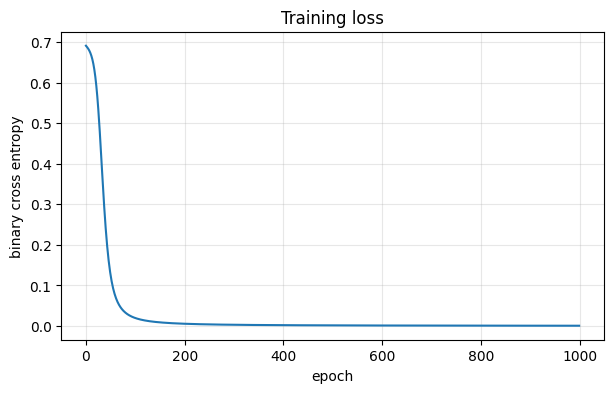

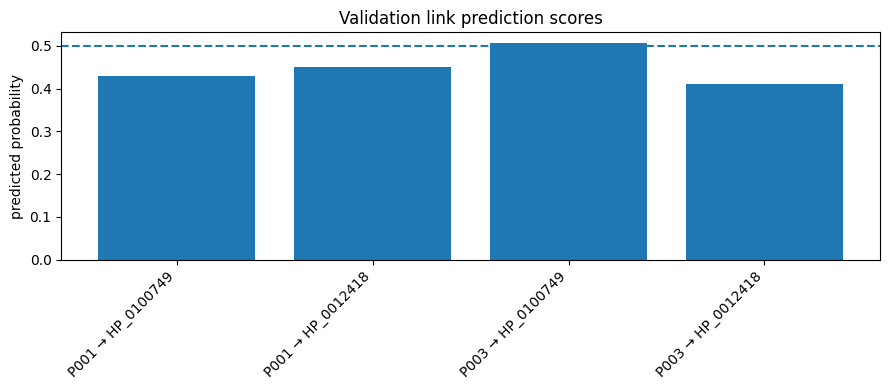

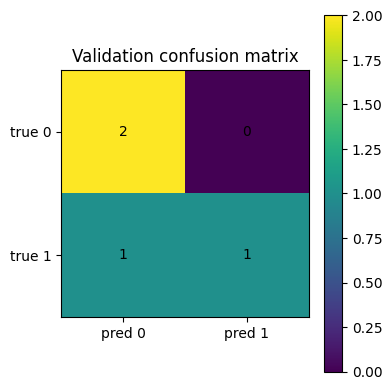

In [22]:
# Inference, accuracy evaluation, and visualization

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def binary_auc(labels, scores):
    # Compute AUC for a small validation set without depending on sklearn.
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    pos_scores = scores[labels == 1]
    neg_scores = scores[labels == 0]
    if len(pos_scores) == 0 or len(neg_scores) == 0:
        return np.nan
    comparisons = []
    for ps in pos_scores:
        for ns in neg_scores:
            if ps > ns:
                comparisons.append(1.0)
            elif ps == ns:
                comparisons.append(0.5)
            else:
                comparisons.append(0.0)
    return float(np.mean(comparisons))

val_logits = np.array(edge_logits(params, val_src, val_dst))
val_scores = sigmoid_np(val_logits)
val_pred = (val_scores >= 0.5).astype(int)
val_true = val_lp["label"].to_numpy()

accuracy = float((val_pred == val_true).mean())
auc = binary_auc(val_true, val_scores)

result_df = val_lp.select(["src", "dst", "label"]).with_columns(
    pl.Series("score", val_scores),
    pl.Series("pred", val_pred),
).with_columns(
    (pl.col("label") == pl.col("pred")).alias("correct")
)

# Add raw labels for readability. Use joins rather than replace.
src_label_df = all_nodes.select(["node_id", "raw_id"]).rename(
    {"node_id": "src", "raw_id": "src_raw"}
)
dst_label_df = all_nodes.select(["node_id", "raw_id"]).rename(
    {"node_id": "dst", "raw_id": "dst_raw"}
)

result_df = (
    result_df
    .join(src_label_df, on="src", how="left")
    .join(dst_label_df, on="dst", how="left")
)

display(
    result_df
    .select(["src_raw", "dst_raw", "label", "score", "pred", "correct"])
    .sort("score", descending=True)
)

print(f"validation accuracy: {accuracy:.3f}")
print(f"validation AUC:      {auc:.3f}")

# 1. loss curve
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("binary cross entropy")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

# 2. validation score visualization
plot_df = result_df.with_columns(
    (
        pl.col("src_raw").cast(pl.String)
        + " → "
        + pl.col("dst_raw").cast(pl.String).str.replace("http://purl.obolibrary.org/obo/", "", literal=True)
    ).alias("edge")
)

plt.figure(figsize=(9, 4))
x = np.arange(plot_df.height)
plt.bar(x, plot_df["score"].to_numpy())
plt.axhline(0.5, linestyle="--")
plt.xticks(x, plot_df["edge"].to_list(), rotation=45, ha="right")
plt.ylabel("predicted probability")
plt.title("Validation link prediction scores")
plt.tight_layout()
plt.show()

# 3. confusion matrix
tp = int(((val_true == 1) & (val_pred == 1)).sum())
tn = int(((val_true == 0) & (val_pred == 0)).sum())
fp = int(((val_true == 0) & (val_pred == 1)).sum())
fn = int(((val_true == 1) & (val_pred == 0)).sum())

cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.title("Validation confusion matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


### Note

These cells implement transductive link prediction on a very small toy dataset.

For a more practical extension, the next steps would be:

1. Add patient and phenotype features.
2. Use `subClassOf` not only as a table but also as a message-passing relation.
3. Replace the encoder with a GraphSAGE- or R-GCN-like model using jraph / Flax.
4. Make negative sampling relation-aware.
5. Use patient-wise or time-wise validation splits.

In this notebook, the goal is to provide the minimal end-to-end bridge from an ontology-derived graph to a JAX link prediction task, then inspect validation-set prediction scores and accuracy.
